# Task 3: Customer Segmentation using K-Means
## 1. Introduction and Data Loading


The objective of this task is to group customers into distinct segments based on their purchasing behavior. I will apply the K-Means clustering algorithm to identify underlying patterns in customer annual income and spending scores to describe the characteristics of each segment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading mall customers dataset
df = pd.read_csv('Mall_Customers.csv')

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


## 2. Exploratory Data Analysis & Preprocessing


Before clustering, we must preprocess the data. K-Means relies on calculating the physical distance between data points. Therefore, we need to extract only the relevant numerical features (like Income and Spending Score) and ensure there are no missing values that could break the algorithm.

In [2]:
# Verification of any missing data that could break the clustering
print("Missing values:\n", df.isnull().sum())

# Annual Income and Spending Score for 2D clustering
# Conversion of pandas columns into a numpy array for sklearn
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print("Shape of X:", X.shape)

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Shape of X: (200, 2)


## 3. Finding the Optimal Number of Clusters (The Elbow Method)
K-Means requires us to specify the number of clusters (K) upfront. To find the optimal 'K', we use the Elbow Method. We will run the algorithm for 1 to 10 clusters and plot the Within-Cluster Sum of Squares (WCSS). The point where the graph bends (the "elbow") indicates the best number of segments.

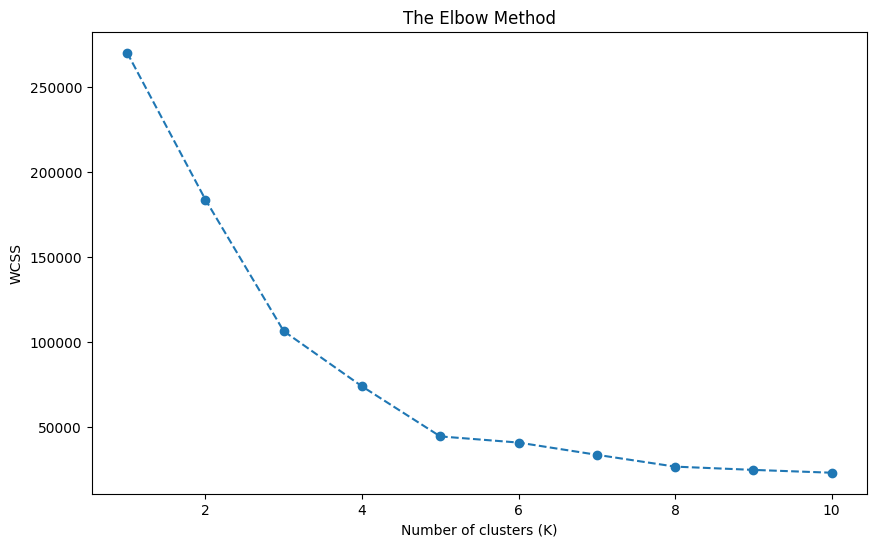

In [3]:
from sklearn.cluster import KMeans

# WCSS (Within-Cluster Sum of Squares)
wcss = []

# Test cluster sizes from 1 to 10
for i in range(1, 11):
    # init='k-means++' to prevent the random initialization trap
    # n_init='auto' for suppress of sklearn warning
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init='auto', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot of Elbow Graph
plt.figure(figsize=(10,6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

## 4. Model Application and Visualization


Now that we know the optimal number of clusters, we can perform the final clustering and visualize the results. This visual representation will allow us to easily identify the different consumer profiles (e.g., high-income/high-spending vs. low-income/low-spending).

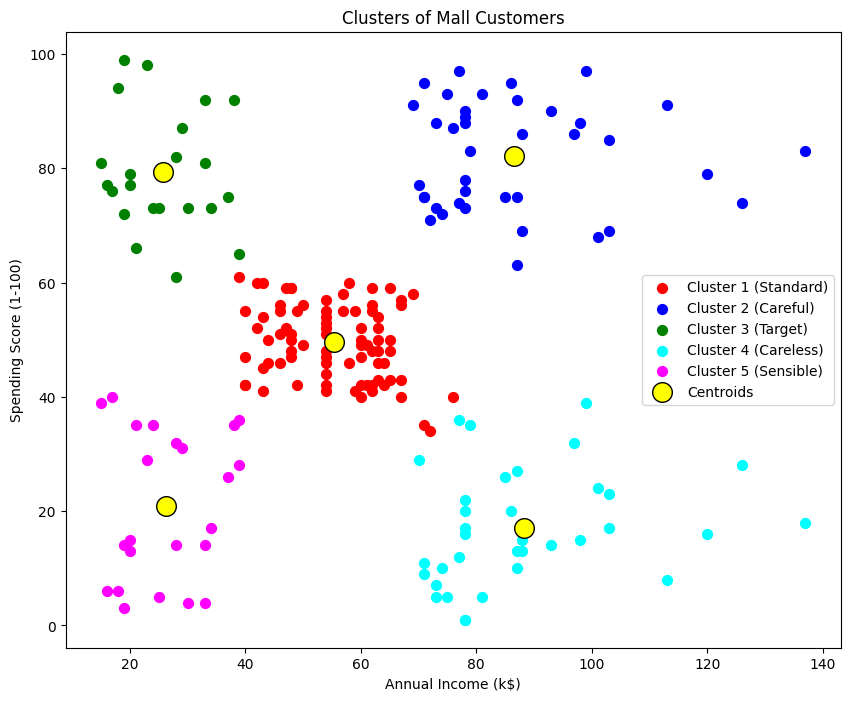

In [4]:
# Training of final model
kmeans = KMeans(n_clusters=5, init='k-means++', n_init='auto', random_state=42)

# fit_predict to calculate the clusters and assign a label (0 to 4) to each customer
y_kmeans = kmeans.fit_predict(X)

# Visualization of 5 clusters using a scatter plot
plt.figure(figsize=(10,8))

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=50, c='red', label='Cluster 1 (Standard)')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=50, c='blue', label='Cluster 2 (Careful)')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=50, c='green', label='Cluster 3 (Target)')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=50, c='cyan', label='Cluster 4 (Careless)')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=50, c='magenta', label='Cluster 5 (Sensible)')

# Plot of centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='yellow', label='Centroids', edgecolors='black')

plt.title('Clusters of Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()